# Bölüm 2 - Python ile Sayısal (Numerical) MLE
Bu bölümde verilen trafik verisi yüklenecek ve Poisson dağılımı için MLE tahmini sayısal olarak bulunacaktır.

In [1]:
#importlar

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Trafik Verisi
traffic_data=np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

# Trafik verisine dair temel bilgiler

print("Trafik Verisi: ", traffic_data)
print("Toplam Gözlem Sayısı:",len(traffic_data))
print("Veri Ortalaması:",np.mean(traffic_data))




Trafik Verisi:  [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
Toplam Gözlem Sayısı: 14
Veri Ortalaması: 12.142857142857142


# Bölüm 2.1 - Negatif Log-Likelihood Fonksiyonu
Bu bölümde Poisson dağılımı için negatif log-likelihood fonksiyonu tanımlanacaktır.
MLE yaklaşımında amaç likelihood'u maksimize etmektir. Sayısal optimizasyonda bunun yerine negatif log-likelihood minimize edilir.

In [2]:
def negative_log_likelihood(lam,data):

    # Poisson dağılımı için negatif log-likelihood fonksiyonu
    # log(k!) terimi optimizasyon sırasında sabit olduğu için ihmal edilmiştir


    lam=np.atleast_1d(lam)[0] #scipy modülü bazen parametreyi tek sayı yerine array([1.0]) gibi döndürebilir önlem olarak bu satır eklenmiştir
    n=len(data)
    total=np.sum(data)

    # Negatif log-likelihood hesaplama

    nll= n*lam-total*np.log(lam)

    return nll



In [3]:
#fonkyiyon testi

test_lambda=12.14

print("NLL(12.14): ",negative_log_likelihood(test_lambda,traffic_data))

NLL(12.14):  -254.44598355732992


# Bölüm 2.2 - Sayısal Optimizasyon ile MLE Tahmini
Bu bölümde negatif log-likelihood fonksiyonu scipy.optimize.minimize kullanılarak minimize edilecek ve Poisson dağılımının MLE ile tahmin edilen lambda parametresi bulunacaktır.

In [4]:
#Başlangıç Tahmini

initial_guess=1.0

#Negatif Likelihood optimizasyonu:

result=opt.minimize(negative_log_likelihood,initial_guess,args=(traffic_data,),bounds=[(0.001,None)])


#Sayısal MLE sonucu:

lambda_numerical=result.x[0]

print("Optimizasyon başarılı mı?",result.success)
print("Optimizasyon Mesajı:",result.message)
print("Sayısal MLE Sonucu (lambda):",lambda_numerical)

Optimizasyon başarılı mı? True
Optimizasyon Mesajı: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Sayısal MLE Sonucu (lambda): 12.1428566075515


In [5]:
#Analitik MLE sonucu:

lambda_analytic=np.mean(traffic_data)

print("Analitik MLE Sonucu (lambda):",lambda_analytic)
print("Sayısal MLE:",lambda_numerical)
print("Aradaki fark:",abs(lambda_numerical-lambda_analytic))

Analitik MLE Sonucu (lambda): 12.142857142857142
Sayısal MLE: 12.1428566075515
Aradaki fark: 5.353056415913215e-07


### Sonuç Yorumu
Sayısal optimizasyon ile bulunan lambda değeri, analitik olarak bulunan örnek ortalaması ile aynıdır.
Bu durum, Poisson dağılımı için MLE tahmininin veri ortalamasına eşit olduğunu sayısal olarak doğrulamaktadır.

# Bölüm 2.3 - Modelin Görselleştirilmesi

Bu bölümde gerçek trafik verisinin histogramı ile tahmin edilen Poisson dağılımı karşılaştırılacaktır.
Amaç, elde edilen λ parametresinin veriyi ne kadar iyi temsil ettiğini görsel olarak incelemektir.

In [6]:
#Poisson dağılımının PMF fonksiyonunu verecek olan modül
from scipy.stats import poisson

In [7]:
#Tahmin edilen lambda değeri
lam_mle=lambda_numerical

# x ekseni değerleri

x=np.arange(min(traffic_data),max(traffic_data)+1)

# Poisson PMF değerleri
pmf_values=poisson.pmf(x,lam_mle)

print("x değerleri:",x)
print("PMF değerleri:",pmf_values)

x değerleri: [ 8  9 10 11 12 13 14 15 16]
PMF değerleri: [0.06244114 0.08424597 0.10229868 0.11292711 0.11427147 0.10673708
 0.09257808 0.07494416 0.05687726]


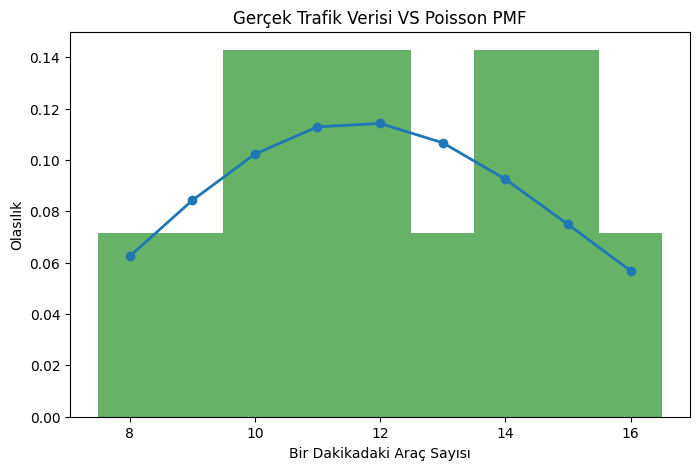

In [8]:
plt.figure(figsize=(8,5))

#Gerçek Veri Histogramı

plt.hist(traffic_data,bins=np.arange(min(traffic_data)-0.5,max(traffic_data)+1.5,1),density=True,alpha=0.6,color='g',label='Gerçek Trafik Verisi')


#Poisson PMF Grafiği

plt.plot(
    x,
    pmf_values,
    'o-',
    linewidth=2,
    label=f"Poisson PMF (λ={lam_mle:.2f})"
)

plt.xlabel("Bir Dakikadaki Araç Sayısı")
plt.ylabel("Olasılık")
plt.title("Gerçek Trafik Verisi VS Poisson PMF")

plt.show()

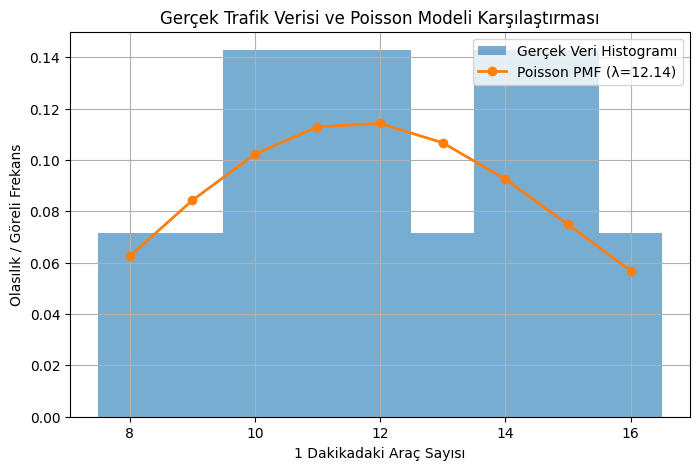

In [9]:
#Rapordaki görsel için bu grafiği kaydediyorum


plt.figure(figsize=(8,5))

plt.hist(
    traffic_data,
    bins=np.arange(min(traffic_data)-0.5, max(traffic_data)+1.5, 1),
    density=True,
    alpha=0.6,
    label="Gerçek Veri Histogramı"
)

plt.plot(
    x,
    pmf_values,
    'o-',
    linewidth=2,
    label=f"Poisson PMF (λ={lam_mle:.2f})"
)

plt.xlabel("1 Dakikadaki Araç Sayısı")
plt.ylabel("Olasılık / Göreli Frekans")
plt.title("Gerçek Trafik Verisi ve Poisson Modeli Karşılaştırması")
plt.legend()
plt.grid(True)

plt.savefig("traffic_poisson_fit.png", dpi=300)
plt.show()

# Bölüm 2.4 - Outlier Analizi

Bu bölümde veri setine yanlışlıkla eklenmiş çok büyük bir gözlemin (200 araç) MLE tahmini üzerindeki etkisi incelenecektir.

Amaç, aykırı değerlerin Poisson dağılımı için yapılan MLE tahminini nasıl değiştirdiğini gözlemlemektir.

In [10]:
#Veri setine outlier ekleyelim

traffic_data_outlier=np.append(traffic_data,200)

print("Yeni veri seti:",traffic_data_outlier)

print("\nYeni veri seti gözlem sayısı:",len(traffic_data_outlier))
print("Yeni ortalama:",np.mean(traffic_data_outlier))

Yeni veri seti: [ 12  15  10   8  14  11  13  16   9  12  11  14  10  15 200]

Yeni veri seti gözlem sayısı: 15
Yeni ortalama: 24.666666666666668


In [11]:
#Yeni veri seti için MLE optimizasyonu

result_outlier=opt.minimize(negative_log_likelihood,initial_guess,args=(traffic_data_outlier,),bounds=[(0.001,None)])
lambda_outlier=result_outlier.x[0]

print("Outlier eklenmiş veri seti için MLE Sonucu (lambda):",lambda_outlier)

Outlier eklenmiş veri seti için MLE Sonucu (lambda): 24.666651246014425


In [12]:
print("Orijinal lambda:", lambda_numerical)
print("Outlier sonrası lambda:", lambda_outlier)

print("Artış miktarı:", lambda_outlier - lambda_numerical)

Orijinal lambda: 12.1428566075515
Outlier sonrası lambda: 24.666651246014425
Artış miktarı: 12.523794638462924


### Outlier Yorumu

Veri setine yalnızca tek bir aykırı gözlem eklenmesine rağmen MLE tahmini yaklaşık 12.14'ten 24.67'ye yükselmiştir.

Bunun nedeni Poisson dağılımı için MLE tahmininin doğrudan örnek ortalamasına eşit olmasıdır. Ortalama ise aykırı değerlere oldukça duyarlıdır.

Bu durum şehir planlamasında ciddi hatalara yol açabilir. Örneğin sistem yolun gerçek kapasitesini olduğundan çok daha yüksek tahmin edebilir. Bunun sonucunda gereksiz yol genişletme kararları alınabilir veya trafik yoğunluğu yanlış yorumlanabilir.

Bu nedenle gerçek veri analizlerinde aykırı değerlerin tespit edilmesi ve veri temizliği yapılması büyük önem taşır.